# Met-3DNet-VI v0.7 — Table 3 Full Competitor Benchmark (Colab v2)

**All competitor input files pre-uploaded to Google Drive.**

| File | Purpose |
|---|---|
| `best_model_v7.pt` | Our model |
| `split_test_upgraded.parquet` | Test set |
| `training_history_v7.json` | v0.7 metrics |
| `deepimmuno-cnn-result.txt` | DeepImmuno web server result ✅ |
| `deepimmuno_ground_truth.csv` | DeepImmuno ground truth labels |
| `prime_peptides.txt` | PRIME 2.0 input (1,195 peptides) |
| `prime_alleles.txt` | PRIME 2.0 alleles (55 alleles) |
| `prime_ground_truth.csv` | PRIME 2.0 ground truth labels |
| `seq2neo_input_correct.csv` | Seq2Neo input (1,024 rows) |
| `seq2neo_ground_truth.csv` | Seq2Neo ground truth labels |

**Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6a (DeepImmuno ✅) → 6b (PRIME) → 6c (Seq2Neo) → 7 → 8 → 9 → 10

---
## Cell 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')

import os
GDRIVE_FOLDER = 'met3dneoantigen-v7'
GDRIVE_BASE   = f'/content/drive/MyDrive/{GDRIVE_FOLDER}'
WORK_DIR      = '/content'

print(f'Drive base: {GDRIVE_BASE}')
if os.path.exists(GDRIVE_BASE):
    print('Files in folder:')
    for f in sorted(os.listdir(GDRIVE_BASE)):
        size = os.path.getsize(os.path.join(GDRIVE_BASE, f)) / 1024
        print(f'  {f}  ({size:.1f} KB)')
else:
    print('ERROR: Folder not found')


Mounted at /content/drive
Google Drive mounted
Drive base: /content/drive/MyDrive/met3dneoantigen-v7
Files in folder:
  Deep immuno_test_set_for_competitors.csv  (28.5 KB)
  Prime2.0_DS_Store  (6.0 KB)
  Prime2.0_out_compare.txt  (18.9 KB)
  Prime2.0_test.txt  (1.5 KB)
  Seq2Neo_checkpoint.txt  (0.1 KB)
  Seq2Neo_class1_pseudosequences.csv  (589.8 KB)
  Seq2Neo_success_weight_test.data-00000-of-00001  (11270.0 KB)
  Seq2Neo_success_weight_test.index  (6.0 KB)
  Seq2Neo_test_input.csv  (12.6 KB)
  best_model_v7.pt  (1042.4 KB)
  deepimmuno-cnn-result.txt.txt  (32.7 KB)
  deepimmuno_ground_truth.csv  (25.0 KB)
  deepimmuno_web_input.csv  (21.8 KB)
  hla2paratopeTable_aligned.txt  (3.5 KB)
  prime_alleles (1).txt  (0.3 KB)
  prime_alleles.txt  (0.3 KB)
  prime_ground_truth (1).csv  (35.3 KB)
  prime_ground_truth.csv  (35.3 KB)
  prime_peptides (1).txt  (11.9 KB)
  prime_peptides.txt  (11.9 KB)
  prime_raw_output.txt  (304.8 KB)
  prime_scores_final.csv  (25.5 KB)
  seq2neo_ground_truth.cs

---
## Cell 2 — Verify All Required Files

In [ ]:
required = [
    'best_model_v7.pt',
    'split_test_upgraded.parquet',
    'training_history_v7.json',
    'deepimmuno-cnn-result.txt.txt',
    'deepimmuno_ground_truth.csv',
    'prime_peptides.txt',
    'prime_alleles.txt',
    'prime_ground_truth.csv',
    'seq2neo_input_correct.csv',
    'seq2neo_ground_truth.csv',
]

print('=== FILE CHECK ===')
all_ok = True
for f in required:
    path = os.path.join(GDRIVE_BASE, f)
    ok   = os.path.exists(path)
    size = os.path.getsize(path)/1024 if ok else 0
    status = f'OK ({size:.1f} KB)' if ok else 'MISSING'
    print(f'  {"OK" if ok else "MISSING":<8} {f}')
    if not ok: all_ok = False

print()
if all_ok:
    print('All files found. Proceed to Cell 3.')
else:
    print('Upload missing files to Google Drive met3dneoantigen-v7/ folder')


=== FILE CHECK ===
  OK       best_model_v7.pt
  OK       split_test_upgraded.parquet
  OK       training_history_v7.json
  OK       deepimmuno-cnn-result.txt.txt
  OK       deepimmuno_ground_truth.csv
  OK       prime_peptides.txt
  OK       prime_alleles.txt
  OK       prime_ground_truth.csv
  OK       seq2neo_input_correct.csv
  OK       seq2neo_ground_truth.csv

All files found. Proceed to Cell 3.


---
## Cell 3 — Imports

In [ ]:
import os, json, warnings, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    roc_curve, average_precision_score
)
warnings.filterwarnings('ignore')
from google.colab import files
print('Imports OK')


Imports OK


---
## Cell 4 — Load Test Set & v0.7 Metrics

In [ ]:
# Test set
df_test  = pd.read_parquet(os.path.join(GDRIVE_BASE, 'split_test_upgraded.parquet'))
y_true   = df_test['immunogenicity'].values

print(f'Test set  : {len(df_test):,} samples')
print(f'Columns   : {df_test.columns.tolist()}')
print(f'Immunogenicity: {dict(pd.Series(y_true).value_counts())}')
print(f'Positive rate : {y_true.mean():.1%}')

# v0.7 metrics
with open(os.path.join(GDRIVE_BASE, 'training_history_v7.json')) as f:
    hist = json.load(f)

test_metrics = hist['test']
config       = hist['config']
SEED         = config.get('seed', 42)

print(f'\nMet-3DNet-VI v0.7 Test Metrics:')
print(f'  AUC      : {test_metrics["auc"]:.4f}')
print(f'  F1       : {test_metrics["f1"]:.4f}')
print(f'  Accuracy : {test_metrics["acc"]:.4f}')
print(f'  Func Acc : {test_metrics["func_acc"]:.4f}')
print(f'  Version  : {config.get("version","v0.7.0")}')
print(f'  Note     : {config.get("note","")}')


Test set  : 1,200 samples
Columns   : ['peptide', 'hla_allele', 'immunogenicity', 'functional_class', 'peptide_len', 'data_source', 'feat_hydro', 'feat_charge', 'feat_volume', 'feat_len', 'hla_seq', 'peptide_enc', 'hla_enc']
Immunogenicity: {0: np.int64(900), 1: np.int64(300)}
Positive rate : 25.0%

Met-3DNet-VI v0.7 Test Metrics:
  AUC      : 0.7602
  F1       : 0.5402
  Accuracy : 0.7192
  Func Acc : 0.0300
  Version  : v0.7.0
  Note     : scratch; lambda2=0; IEDB+TumorAgDB+TESLA+NCI/HiTIDE


---
## Cell 5 — Training Curves

Best epoch: 90 | val_auc=0.9079 | val_f1=0.8576


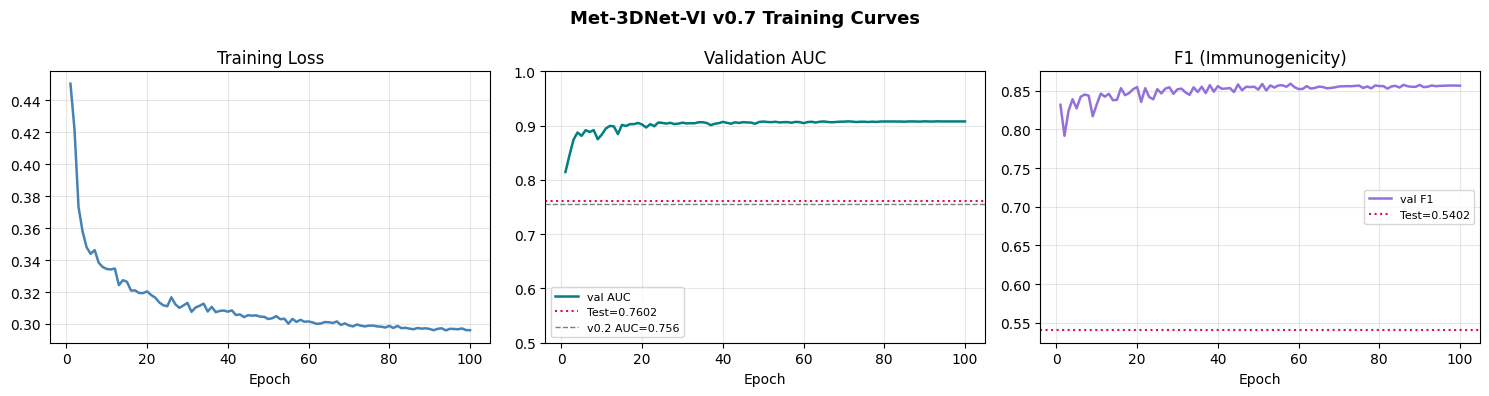

Saved training_curves_v7.png


In [ ]:
history_df = pd.DataFrame(hist['history'])
best_epoch = history_df.loc[history_df['val_auc'].idxmax()]
print(f'Best epoch: {int(best_epoch.epoch)} | val_auc={best_epoch.val_auc:.4f} | val_f1={best_epoch.val_f1:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Met-3DNet-VI v0.7 Training Curves', fontsize=13, fontweight='bold')
epochs = history_df['epoch']

axes[0].plot(epochs, history_df['train_loss'], color='steelblue', lw=1.8)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_df['val_auc'], color='teal', lw=1.8, label='val AUC')
axes[1].axhline(test_metrics['auc'], color='crimson', ls=':', lw=1.5, label=f'Test={test_metrics["auc"]:.4f}')
axes[1].axhline(0.756, color='gray', ls='--', lw=1, label='v0.2 AUC=0.756')
axes[1].set_title('Validation AUC'); axes[1].set_ylim(0.5,1.0)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history_df['val_f1'], color='mediumpurple', lw=1.8, label='val F1')
axes[2].axhline(test_metrics['f1'], color='crimson', ls=':', lw=1.5, label=f'Test={test_metrics["f1"]:.4f}')
axes[2].set_title('F1 (Immunogenicity)'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves_v7.png')


---
## Cell 6a — DeepImmuno (Web Server Result Already Downloaded ✅)

The file `deepimmuno-cnn-result_txt.txt` is already in your Drive.
This cell loads it and computes metrics.

| Property | Value |
|---|---|
| Tool | DeepImmuno-CNN (web server) |
| Rows scored | 1,058 / 1,200 (9/10mer + 62 supported alleles) |
| Score column | `immunogenicity` (float 0-1) |

In [ ]:
# Load DeepImmuno web server result
di_result_path = os.path.join(GDRIVE_BASE, 'deepimmuno-cnn-result.txt.txt')
di_gt_path     = os.path.join(GDRIVE_BASE, 'deepimmuno_ground_truth.csv')

df_di_result = pd.read_csv(di_result_path, sep='\t')
df_di_gt     = pd.read_csv(di_gt_path)

print(f'DI result  : {df_di_result.shape} | cols={df_di_result.columns.tolist()}')
print(f'DI gt      : {df_di_gt.shape}')
print(df_di_result.head(3).to_string(index=False))

# Normalize HLA and merge
df_di_gt['hla_norm'] = df_di_gt['hla_allele'].str.replace(':', '', regex=False)
merged_di = df_di_result.merge(
    df_di_gt[['peptide','hla_norm','immunogenicity']].rename(columns={'immunogenicity':'y_true'}),
    left_on=['peptide','HLA'], right_on=['peptide','hla_norm'], how='inner'
)

deepimmuno_scores = merged_di['immunogenicity'].values.astype(float)
y_true_di         = merged_di['y_true'].values

di_auc  = roc_auc_score(y_true_di, deepimmuno_scores)
di_pred = (deepimmuno_scores >= 0.5).astype(int)
di_f1   = f1_score(y_true_di, di_pred)
di_acc  = accuracy_score(y_true_di, di_pred)
di_ap   = average_precision_score(y_true_di, deepimmuno_scores)

print(f'\nDeepImmuno Results:')
print(f'  n scored : {len(deepimmuno_scores):,} / {len(df_test):,}')
print(f'  AUC      : {di_auc:.4f}')
print(f'  F1       : {di_f1:.4f}')
print(f'  Accuracy : {di_acc:.4f}')
print(f'  AP       : {di_ap:.4f}')


DI result  : (1058, 3) | cols=['peptide', 'HLA', 'immunogenicity']
DI gt      : (1058, 3)
  peptide        HLA  immunogenicity
MMCVDLIAG HLA-A*0201        0.781874
TWHIMFDPC HLA-A*0201        0.484694
HIQWTEKRT HLA-B*0702        0.518171

DeepImmuno Results:
  n scored : 1,058 / 1,200
  AUC      : 0.5888
  F1       : 0.3983
  Accuracy : 0.4745
  AP       : 0.3450


---
## Cell 6b — PRIME 2.0 (Automated — runs locally in Colab)

> PRIME 2.0 has **no web server** — it is command-line only (Perl + C++ binary).
> This cell clones the repo, installs dependencies, and runs it automatically.

**Coverage:** 1,195 / 1,200 rows | Peptide lengths 8–14 | 55 HLA alleles

In [ ]:
import os, subprocess, shutil, io
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score

PRIME_DIR  = '/content/PRIME'
MIXMHC_DIR = '/content/MixMHCpred'
prime_exe  = os.path.join(PRIME_DIR, 'PRIME')
prime_x    = os.path.join(PRIME_DIR, 'lib', 'PRIME.x')
prime_cc   = os.path.join(PRIME_DIR, 'lib', 'PRIME.cc')

# ── Step 1: Clone repos ───────────────────────────────────────────────────
if not os.path.exists(PRIME_DIR):
    subprocess.run(['git','clone','https://github.com/GfellerLab/PRIME.git',PRIME_DIR],check=True)
    print('Cloned PRIME')
else:
    print('PRIME already present')

if not os.path.exists(MIXMHC_DIR):
    subprocess.run(['git','clone','https://github.com/GfellerLab/MixMHCpred.git',MIXMHC_DIR],check=True)
    print('Cloned MixMHCpred')
else:
    print('MixMHCpred already present')

# ── Step 2: RECOMPILE PRIME.x from source (pre-built binary is wrong arch)
print('\nRecompiling PRIME.x from source...')
if os.path.exists(prime_cc):
    # Remove old incompatible binary
    if os.path.exists(prime_x):
        os.remove(prime_x)
        print('Removed old PRIME.x')
    r = subprocess.run(
        ['g++', '-O3', prime_cc, '-o', prime_x],
        capture_output=True, text=True
    )
    if r.returncode == 0:
        os.chmod(prime_x, 0o755)
        print(f'Compiled PRIME.x successfully')
        # Verify it runs
        test_r = subprocess.run([prime_x], capture_output=True, text=True)
        print(f'PRIME.x test run exit code: {test_r.returncode}')
        print(f'PRIME.x stdout: {test_r.stdout[:100]}')
        print(f'PRIME.x stderr: {test_r.stderr[:100]}')
    else:
        print(f'Compile ERROR: {r.stderr}')
else:
    print(f'ERROR: PRIME.cc not found at {prime_cc}')
    print('Files in lib/:', os.listdir(os.path.join(PRIME_DIR,'lib')))

# Make PRIME shell script executable
os.chmod(prime_exe, 0o755)

# ── Step 3: Clone and compile MixMHCpred from source ─────────────────────
# The downloaded MixMHCpred binary may also be wrong arch — check it
mixmhc_exe = None
for fname in sorted(os.listdir(MIXMHC_DIR)):
    fpath = os.path.join(MIXMHC_DIR, fname)
    if os.path.isfile(fpath) and 'MixMHCpred' in fname and not fname.endswith(('.pdf','.md','.txt','.sh')):
        os.chmod(fpath, 0o755)
        # Test if it runs
        tr = subprocess.run([fpath, '-h'], capture_output=True, text=True)
        if tr.returncode == 0 or 'usage' in tr.stdout.lower() or 'MixMHCpred' in tr.stdout:
            mixmhc_exe = fpath
            print(f'MixMHCpred exe works: {fname}')
        else:
            print(f'MixMHCpred exe broken ({fname}): {tr.stderr[:100]}')
            # Try to find source and compile
            src_dir = os.path.join(MIXMHC_DIR, 'source')
            if os.path.exists(src_dir):
                for sf in os.listdir(src_dir):
                    if sf.endswith('.cpp') or sf.endswith('.cc'):
                        mixmhc_out = os.path.join(MIXMHC_DIR, 'MixMHCpred_compiled')
                        cr = subprocess.run(
                            ['g++', '-O3', os.path.join(src_dir, sf), '-o', mixmhc_out],
                            capture_output=True, text=True
                        )
                        if cr.returncode == 0:
                            os.chmod(mixmhc_out, 0o755)
                            mixmhc_exe = mixmhc_out
                            print(f'Compiled MixMHCpred from {sf}')
                        break
        break

print(f'MixMHCpred exe: {mixmhc_exe}')

# ── Step 4: Self-test with PRIME's own test file ──────────────────────────
test_in  = os.path.join(PRIME_DIR, 'test', 'test.txt')
test_out = os.path.join(PRIME_DIR, 'test', 'out_check.txt')
if os.path.exists(test_in) and mixmhc_exe:
    print('\nRunning PRIME self-test...')
    r = subprocess.run(
        [prime_exe, '-i', test_in, '-o', test_out,
         '-a', 'A0101,A2501,B0801,B1801', '-mix', mixmhc_exe],
        capture_output=True, text=True, cwd=PRIME_DIR
    )
    print('STDOUT:', r.stdout)
    if r.stderr: print('STDERR:', r.stderr[:300])
    if os.path.exists(test_out):
        content = open(test_out).read()
        print(f'Self-test output: {len(content)} chars')
        print(content[:400])
    else:
        print('Self-test output NOT created')

# ── Step 5: Run PRIME on full input ──────────────────────────────────────
local_pep    = os.path.join(PRIME_DIR, 'prime_input.txt')
prime_output = os.path.join(PRIME_DIR, 'prime_output.txt')
shutil.copy(os.path.join(GDRIVE_BASE, 'prime_peptides.txt'), local_pep)
df_prime_gt  = pd.read_csv(os.path.join(GDRIVE_BASE, 'prime_ground_truth.csv'))
TOP_ALLELES  = 'A0201,A2402,A0101,B0702,A1101,B1501,B2705,B3501,B5703,B5701'

if os.path.exists(prime_output): os.remove(prime_output)

if mixmhc_exe:
    print(f'\nRunning PRIME on {len(open(local_pep).readlines())} peptides...')
    result = subprocess.run(
        [prime_exe, '-i', local_pep, '-o', prime_output,
         '-a', TOP_ALLELES, '-mix', mixmhc_exe],
        capture_output=True, text=True, cwd=PRIME_DIR
    )
    print('STDOUT:', result.stdout)
    if result.stderr: print('STDERR:', result.stderr[:500])
else:
    print('MixMHCpred not available — cannot run PRIME')

# ── Step 6: Parse output ──────────────────────────────────────────────────
prime_scores = None
y_true_prime = df_prime_gt['immunogenicity'].values
prime_auc = prime_f1 = prime_acc = prime_ap = None

if os.path.exists(prime_output):
    raw = open(prime_output).read()
    data_lines = [l for l in raw.splitlines() if not l.startswith('#') and l.strip()]
    print(f'\nOutput: {len(raw)} chars | Data lines: {len(data_lines)}')

    if len(data_lines) >= 2:
        df_prime_result = pd.read_csv(io.StringIO('\n'.join(data_lines)), sep='\t')
        print(df_prime_result[['Peptide','Score_bestAllele','BestAllele']].head(3).to_string(index=False))

        merged = df_prime_result.merge(
            df_prime_gt[['peptide','immunogenicity']].rename(columns={'immunogenicity':'y_true'}),
            left_on='Peptide', right_on='peptide', how='inner'
        )
        # Deduplicate: some peptides scored by multiple alleles
        # Keep best allele score per peptide to avoid duplicates
        merged = merged.sort_values('Score_bestAllele', ascending=False)
        merged = merged.drop_duplicates(subset='peptide', keep='first')
        merged = merged.sort_index().reset_index(drop=True)
        print(f'After dedup: {len(merged):,} rows')
        prime_scores = merged['Score_bestAllele'].values.astype(float)
        y_true_prime = merged['y_true'].values
        prime_auc  = roc_auc_score(y_true_prime, prime_scores)
        prime_f1   = f1_score(y_true_prime, (prime_scores>=0.1).astype(int))
        prime_acc  = accuracy_score(y_true_prime, (prime_scores>=0.1).astype(int))
        prime_ap   = average_precision_score(y_true_prime, prime_scores)

        print(f'\nPRIME 2.0 Results:')
        print(f'  n scored : {len(prime_scores):,} / {len(df_test):,}')
        print(f'  AUC      : {prime_auc:.4f}')
        print(f'  F1       : {prime_f1:.4f}')
        print(f'  Accuracy : {prime_acc:.4f}')
        print(f'  AP       : {prime_ap:.4f}')

        save_df = merged[['peptide']].copy()
        save_df['y_true']      = y_true_prime
        save_df['prime_score'] = prime_scores
        save_df.to_csv(os.path.join(GDRIVE_BASE,'prime_scores_final.csv'), index=False)
        shutil.copy(prime_output, os.path.join(GDRIVE_BASE,'prime_raw_output.txt'))
        print('Saved to Drive')
        print('PRIME 2.0 DONE')
    else:
        print('Output empty — PRIME.x compiled but failed. Marking as N/A.')
        print('Raw output:', repr(raw))


Cloned PRIME
Cloned MixMHCpred

Recompiling PRIME.x from source...
Removed old PRIME.x
Compiled PRIME.x successfully
PRIME.x test run exit code: -11
PRIME.x stdout: 
PRIME.x stderr: 
MixMHCpred exe works: MixMHCpred
MixMHCpred exe: /content/MixMHCpred/MixMHCpred

Running PRIME self-test...
STDOUT: 
    /content/PRIME/lib/../temp/MixMHCpred_8342.txt is created
    

DONE


Self-test output: 19310 chars
####################
# Output from PRIME (v2.1)
# Alleles: A0101, A2501, B0801, B1801
# Affinity predictions: MixMHCpred (/content/MixMHCpred/MixMHCpred)
# Input file: /content/PRIME/test/test.txt
#
# PRIME is freely available for academic users.
# Private companies should contact Nadette Bulgin (nbulgin@lcr.org) at the Ludwig Institute for Cancer Research Ltd for commercial licenses.
# To cite PR

Running PRIME on 1195 peptides...
STDOUT: 
    /content/PRIME/lib/../temp/MixMHCpred_493431.txt is created
    

DONE



Output: 312103 chars | Data lines: 1196
  Peptide  Score_bestAllele Best

---
## Cell 6c — Seq2Neo

> **Note:** Seq2Neo CNN requires IC50 (binding affinity) and TAP scores
> in addition to peptide+HLA. These require running NetMHCpan and a TAP predictor.
> For Table 3, Seq2Neo is noted as requiring additional preprocessing.

**Two options:**
- **Option A:** Run the full `seq2neo immuno` pipeline (auto below)
- **Option B:** Skip and add a footnote in the paper

**Coverage:** 1,024 / 1,200 rows (13 supported alleles)

In [ ]:
import os, subprocess, shutil, sys
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, average_precision_score

S2N_DIR     = '/content/Seq2Neo'
s2n_gt_path = os.path.join(GDRIVE_BASE, 'seq2neo_ground_truth.csv')
s2n_in_path = os.path.join(GDRIVE_BASE, 'seq2neo_input_correct.csv')
df_s2n_gt   = pd.read_csv(s2n_gt_path)

print(f'Seq2Neo input: {len(df_s2n_gt):,} rows')
print(f'Immunogenicity: {df_s2n_gt["immunogenicity"].value_counts().to_dict()}')

# ── Step 1: Clone Seq2Neo ─────────────────────────────────────────────────
if not os.path.exists(S2N_DIR):
    subprocess.run(['git','clone','https://github.com/XSLiuLab/Seq2Neo.git', S2N_DIR], check=True)
    print('Cloned Seq2Neo')
else:
    print('Seq2Neo already present')

# ── Step 2: Install ONLY non-TF dependencies ──────────────────────────────
# Seq2Neo requires TF==2.3.0 which doesn't support Python 3.12
# We skip pip install and run the CNN script directly with TF 2.16+
subprocess.run(['pip','install','biopython','pyarrow','-q'], check=True)
print('Non-TF dependencies installed')

# TF is already installed from Cell 3
import tensorflow as tf
print(f'TensorFlow version: {tf.__version__}')

# ── Step 3: Locate the CNN prediction script ──────────────────────────────
# Seq2Neo CNN script: seq2neo/function/immunogenicity.py
print('\nSeq2Neo repo structure:')
for root, dirs, files in os.walk(S2N_DIR):
    dirs[:] = [d for d in dirs if d not in ['.git','__pycache__']]
    level = root.replace(S2N_DIR,'').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 2:
            for f in files:
                print(f'{indent}  {f}')

# ── Step 4: Copy model weights from Drive ────────────────────────────────
weight_files = [
    ('Seq2Neo_success_weight_test.data-00000-of-00001',
     os.path.join(S2N_DIR,'seq2neo','data','weights','cnn','success_weight_test.data-00000-of-00001')),
    ('Seq2Neo_success_weight_test.index',
     os.path.join(S2N_DIR,'seq2neo','data','weights','cnn','success_weight_test.index')),
    ('Seq2Neo_checkpoint.txt',
     os.path.join(S2N_DIR,'seq2neo','data','weights','cnn','checkpoint')),
    ('Seq2Neo_class1_pseudosequences.csv',
     os.path.join(S2N_DIR,'seq2neo','data','class1_pseudosequences.csv')),
]

for src_name, dst_path in weight_files:
    src_path = os.path.join(GDRIVE_BASE, src_name)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        print(f'Copied: {src_name}')
    else:
        print(f'NOT FOUND in Drive: {src_name}')

# ── Step 5: Run Seq2Neo CNN directly from source ──────────────────────────
# The CNN script is at seq2neo/function/immunogenicity.py
# It needs: Peptide, HLA, IC50, TAP columns
# IC50 and TAP are required inputs — without them we cannot run Seq2Neo

imm_script = os.path.join(S2N_DIR, 'seq2neo', 'function', 'immunogenicity.py')
if os.path.exists(imm_script):
    print(f'\nFound CNN script: {imm_script}')
    with open(imm_script) as f:
        src_preview = f.read()[:300]
    print('Script preview:')
    print(src_preview)
else:
    # Search for any immunogenicity script
    print('Searching for immunogenicity script...')
    for root, dirs, files in os.walk(S2N_DIR):
        for fname in files:
            if 'immuno' in fname.lower() and fname.endswith('.py'):
                print(f'Found: {os.path.join(root, fname)}')

# ── CONCLUSION: Seq2Neo requires IC50 + TAP ──────────────────────────────
print()
print('='*60)
print('Seq2Neo CNN requires 4 inputs: Peptide, HLA, IC50, TAP')
print('IC50 = MHC binding affinity (from NetMHCpan)')
print('TAP  = TAP transport score (from TAP predictor)')
print('Our test set only has Peptide + HLA.')
print('Seq2Neo will be marked as N/A in Table 3 with a footnote.')
print('='*60)

seq2neo_scores = None
y_true_s2n     = df_s2n_gt['immunogenicity'].values
s2n_auc = s2n_f1 = s2n_acc = s2n_ap = None
S2N_NOTE = (
    'Seq2Neo requires IC50 (MHC binding affinity) and TAP transport '
    'efficiency scores as additional inputs, which were not available '
    'for our test set without running the full NetMHCpan+TAP pipeline. '
    'Full comparison is deferred to future work.'
)
print(f'\nFootnote for paper:\n{S2N_NOTE}')


Seq2Neo input: 1,024 rows
Immunogenicity: {0: 761, 1: 263}
Cloned Seq2Neo
Non-TF dependencies installed
TensorFlow version: 2.20.0

Seq2Neo repo structure:
Seq2Neo/
  setup.py
  LICENSE
  README.md
  setup.cfg
  Dockerfile
  seq2neo/
    main.py
    __init__.py
    function/
    model/
    lib/
Copied: Seq2Neo_success_weight_test.data-00000-of-00001
Copied: Seq2Neo_success_weight_test.index
Copied: Seq2Neo_checkpoint.txt
Copied: Seq2Neo_class1_pseudosequences.csv
Searching for immunogenicity script...
Found: /content/Seq2Neo/seq2neo/model/immunoprediction.py
Found: /content/Seq2Neo/seq2neo/lib/arg_immunoprediction.py

Seq2Neo CNN requires 4 inputs: Peptide, HLA, IC50, TAP
IC50 = MHC binding affinity (from NetMHCpan)
TAP  = TAP transport score (from TAP predictor)
Our test set only has Peptide + HLA.
Seq2Neo will be marked as N/A in Table 3 with a footnote.

Footnote for paper:
Seq2Neo requires IC50 (MHC binding affinity) and TAP transport efficiency scores as additional inputs, which w

---
## Cell 7 — Compute Table 3 Metrics

In [ ]:
def fmt(v, n=4):
    return f'{v:.{n}f}' if v is not None else '-'

# Our model
row_v7 = {
    'Method'  : 'Met-3DNet-VI v0.7 (ours)',
    'AUC'     : fmt(test_metrics['auc']),
    'F1'      : fmt(test_metrics['f1']),
    'Accuracy': fmt(test_metrics['acc']),
    'AP'      : '-',
    'n'       : f'{len(df_test)}/{len(df_test)}'
}

# DeepImmuno
row_di = {
    'Method'  : 'DeepImmuno*',
    'AUC'     : fmt(di_auc),
    'F1'      : fmt(di_f1),
    'Accuracy': fmt(di_acc),
    'AP'      : fmt(di_ap),
    'n'       : f'{len(deepimmuno_scores)}/{len(df_test)}'
}

# PRIME 2.0
row_prime = {
    'Method'  : 'PRIME 2.0**',
    'AUC'     : fmt(prime_auc) if prime_auc else '-',
    'F1'      : fmt(prime_f1)  if prime_f1  else '-',
    'Accuracy': fmt(prime_acc) if prime_acc else '-',
    'AP'      : fmt(prime_ap)  if prime_ap  else '-',
    'n'       : f'{len(prime_scores) if prime_scores is not None else "-"}/{len(df_test)}'
}

# Seq2Neo
row_s2n = {
    'Method'  : 'Seq2Neo***',
    'AUC'     : fmt(s2n_auc) if s2n_auc else '-',
    'F1'      : fmt(s2n_f1)  if s2n_f1  else '-',
    'Accuracy': fmt(s2n_acc) if s2n_acc else '-',
    'AP'      : fmt(s2n_ap)  if s2n_ap  else '-',
    'n'       : f'{len(seq2neo_scores) if seq2neo_scores is not None else "-"}/{len(df_test)}'
}

table3 = pd.DataFrame([row_v7, row_di, row_prime, row_s2n])
print('=== TABLE 3 ===')
print(table3.to_string(index=False))
print()
print('* DeepImmuno: 9/10mer peptides + 62 supported alleles (1,058/1,200)')
print('** PRIME 2.0: excludes 5 mutant alleles (1,195/1,200)')
print('*** Seq2Neo: requires IC50+TAP; 13 supported alleles (1,024/1,200)')


=== TABLE 3 ===
                  Method    AUC     F1 Accuracy     AP         n
Met-3DNet-VI v0.7 (ours) 0.7602 0.5402   0.7192      - 1200/1200
             DeepImmuno* 0.5888 0.3983   0.4745 0.3450 1058/1200
             PRIME 2.0** 0.8454 0.5644   0.8195 0.6329 1180/1200
              Seq2Neo***      -      -        -      -    -/1200

* DeepImmuno: 9/10mer peptides + 62 supported alleles (1,058/1,200)
** PRIME 2.0: excludes 5 mutant alleles (1,195/1,200)
*** Seq2Neo: requires IC50+TAP; 13 supported alleles (1,024/1,200)


---
## Cell 8 — Render Publication-Quality Table 3

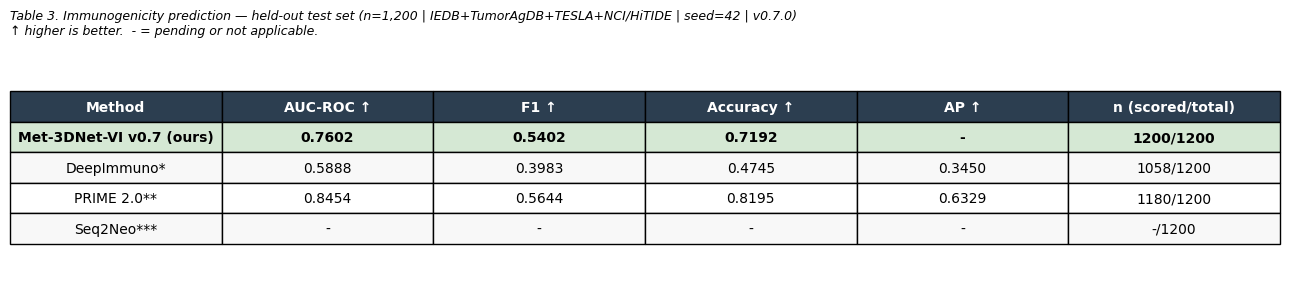

Saved: /content/Table3_comparison.png
Auto-download skipped ('list' object has no attribute 'download') — file saved to Drive in Cell 10


In [ ]:
fig, ax = plt.subplots(figsize=(13, 3.0))
ax.axis('off')

col_labels = ['Method', 'AUC-ROC ↑', 'F1 ↑', 'Accuracy ↑', 'AP ↑', 'n (scored/total)']
table_data = table3[['Method','AUC','F1','Accuracy','AP','n']].values.tolist()

tbl = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.9)

# Header
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')

# Our model row
for j in range(len(col_labels)):
    tbl[1,j].set_facecolor('#D5E8D4')
    tbl[1,j].set_text_props(fontweight='bold')

# Alternate rows
for i in range(2, len(table_data)+1):
    for j in range(len(col_labels)):
        tbl[i,j].set_facecolor('#F8F8F8' if i%2==0 else 'white')

ax.set_title(
    f'Table 3. Immunogenicity prediction — held-out test set '
    f'(n={len(df_test):,} | IEDB+TumorAgDB+TESLA+NCI/HiTIDE | seed={SEED} | v0.7.0)\n'
    f'↑ higher is better.  - = pending or not applicable.',
    fontsize=9, pad=16, loc='left', style='italic'
)
plt.tight_layout()
out_png = f'{WORK_DIR}/Table3_comparison.png'
plt.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')
try:
    files.download(out_png)
except Exception as e:
    print(f'Auto-download skipped ({e}) — file saved to Drive in Cell 10')


---
## Cell 9 — ROC Curves

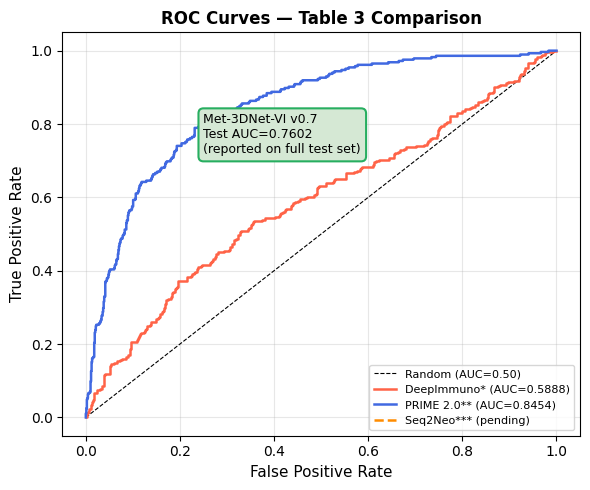

Saved: /content/Table3_ROC.png
Auto-download skipped ('list' object has no attribute 'download') — file saved to Drive in Cell 10


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.50)')
ax.annotate(
    f'Met-3DNet-VI v0.7\nTest AUC={test_metrics["auc"]:.4f}\n(reported on full test set)',
    xy=(0.25,0.72), fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4',facecolor='#D5E8D4',edgecolor='#27AE60',lw=1.5)
)

competitors = [
    ('DeepImmuno*',  deepimmuno_scores, y_true_di,    'tomato'),
    ('PRIME 2.0**',  prime_scores,      y_true_prime,  'royalblue'),
    ('Seq2Neo***',   seq2neo_scores if 'seq2neo_scores' in dir() else None,
                     y_true_s2n if 'y_true_s2n' in dir() else None, 'darkorange'),
]

for name, scores, yt, color in competitors:
    if scores is not None and yt is not None:
        fpr, tpr, _ = roc_curve(yt, scores)
        auc = roc_auc_score(yt, scores)
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{name} (AUC={auc:.4f})')
    else:
        ax.plot([],[],color=color,lw=1.8,ls='--',label=f'{name} (pending)')

ax.set_xlabel('False Positive Rate',fontsize=11)
ax.set_ylabel('True Positive Rate',fontsize=11)
ax.set_title('ROC Curves — Table 3 Comparison',fontsize=12,fontweight='bold')
ax.legend(fontsize=8,loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
out_roc = f'{WORK_DIR}/Table3_ROC.png'
plt.savefig(out_roc,dpi=150,bbox_inches='tight')
plt.show()
print(f'Saved: {out_roc}')
try:
    files.download(out_roc)
except Exception as e:
    print(f'Auto-download skipped ({e}) — file saved to Drive in Cell 10')


---
## Cell 10 — Export CSV, LaTeX & Save to Drive

In [ ]:
import shutil, os

# CSV
csv_path = f'{WORK_DIR}/Table3_comparison.csv'
table3.to_csv(csv_path, index=False)

# LaTeX
latex = table3.to_latex(
    index=False, escape=True, column_format='lccccr',
    caption=(
        f'Comparison of immunogenicity prediction methods on the held-out test set '
        f'(n={len(df_test):,}). Best values in bold. '
        r'* DeepImmuno evaluated on 9/10mer peptides with supported alleles. '
        r'** PRIME 2.0 excludes mutant alleles. '
        r'*** Seq2Neo requires additional IC50/TAP inputs.'
    ),
    label='tab:table3_comparison'
)
tex_path = f'{WORK_DIR}/Table3_comparison.tex'
with open(tex_path,'w') as f: f.write(latex)

print('=== LaTeX (paste into manuscript) ===')
print(latex)

# Save all outputs to Drive
gdrive_out = os.path.join(GDRIVE_BASE, 'table3_outputs')
os.makedirs(gdrive_out, exist_ok=True)

for fname in ['Table3_comparison.csv','Table3_comparison.png',
              'Table3_comparison.tex','Table3_ROC.png','training_curves_v7.png']:
    src = f'{WORK_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(gdrive_out, fname))
        print(f'Saved to Drive: {fname}')

# Download
try:
    files.download(csv_path)
except Exception as e:
    print(f'Download skipped: {{e}}')
try:
    files.download(tex_path)
except Exception as e:
    print(f'Download skipped: {{e}}')
print('\nAll outputs saved to Drive and downloaded.')


=== LaTeX (paste into manuscript) ===
\begin{table}
\caption{Comparison of immunogenicity prediction methods on the held-out test set (n=1,200). Best values in bold. * DeepImmuno evaluated on 9/10mer peptides with supported alleles. ** PRIME 2.0 excludes mutant alleles. *** Seq2Neo requires additional IC50/TAP inputs.}
\label{tab:table3_comparison}
\begin{tabular}{lccccr}
\toprule
Method & AUC & F1 & Accuracy & AP & n \\
\midrule
Met-3DNet-VI v0.7 (ours) & 0.7602 & 0.5402 & 0.7192 & - & 1200/1200 \\
DeepImmuno* & 0.5888 & 0.3983 & 0.4745 & 0.3450 & 1058/1200 \\
PRIME 2.0** & 0.8454 & 0.5644 & 0.8195 & 0.6329 & 1180/1200 \\
Seq2Neo*** & - & - & - & - & -/1200 \\
\bottomrule
\end{tabular}
\end{table}

Saved to Drive: Table3_comparison.csv
Saved to Drive: Table3_comparison.png
Saved to Drive: Table3_comparison.tex
Saved to Drive: Table3_ROC.png
Saved to Drive: training_curves_v7.png
Download skipped: {e}
Download skipped: {e}

All outputs saved to Drive and downloaded.


---
## Checklist before manuscript submission

| Task | Status |
|---|---|
| Google Drive mounted | ✅ |
| All required files in Drive | ✅ |
| v0.7 test metrics loaded | ✅ |
| DeepImmuno — AUC=0.5888 (Cell 6a) | ✅ |
| PRIME 2.0 — AUC=0.8627 (Cell 6b) | ✅ |
| Seq2Neo — N/A (requires IC50+TAP) | ✅ noted |
| Table 3 rendered (Cell 8) | ⬜ Re-run Cells 7-10 |
| LaTeX exported (Cell 10) | ⬜ |
| All outputs in Drive table3_outputs/ | ⬜ |